In [7]:
#connect to colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Dataset paths:
WORK_DIR_ROOT = '/content/drive/MyDrive/datasets/Master/'
DATASET_ROOT = '/content/drive/MyDrive/datasets/Master/datasets_orig'
METADATA_TRAIN_PATH = f"{DATASET_ROOT}/MILK10k_Training_Metadata.csv"
METADATA_TEST_PATH = f"{DATASET_ROOT}/MILK10k_Test_Metadata.csv"
#DATASET_TRAIN_ZIP = f"{DATASET_ROOT}/MILK10k_Training_Input.zip"
DATASET_TRAIN = f"{DATASET_ROOT}/MILK10k_Training_Input/MILK10k_Training_Input/"
DATASET_RESIZED = f"{WORK_DIR_ROOT}/datasets_resized_stratified/"
GT_PATH = f"{DATASET_ROOT}/MILK10k_Training_GroundTruth.csv"

In [3]:
# important for import of the utils file.
import sys
sys.path.append(WORK_DIR_ROOT)
from utils import *

In [4]:
#
import numpy
print(numpy.__version__)

2.0.2


## 1. Create stratified train/test/val datasets
### 1.1 Combine metadata with labels:


In [5]:
import pandas as pd

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)
print(f"rows, cols -> {df_train_orig.shape}")
df_train_orig.head()

rows, cols -> (10480, 17)


,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,MONET_ulceration_crust,MONET_hair,MONET_vasculature_vessels,MONET_erythema,MONET_pigmented,MONET_gel_water_drop_fluid_dermoscopy_liquid,MONET_skin_markings_pen_ink_purple_pen
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,0.166749,0.163601,0.002284,0.124315,0.719495,0.220399,0.237601
1,IL_0000652,dermoscopic,ISIC_4671410,MILK study team,CC-BY-NC,instrument only,70.0,male,1,head_neck_face,0.659859,0.156478,0.016397,0.032357,0.847014,0.138121,0.148776
2,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,0.348609,0.614718,0.013415,0.447485,0.061977,0.296341,0.058006
3,IL_0003176,dermoscopic,ISIC_5371928,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,0.392950,0.897668,0.367882,0.645776,0.122108,0.719937,0.329812
4,IL_0004688,clinical: close-up,ISIC_0791494,MILK study team,CC-BY-NC,instrument only,50.0,male,3,lower_extremity,0.889925,0.120788,0.004546,0.487298,0.036550,0.146776,0.086027


In [56]:
df_gt = pd.read_csv(GT_PATH)
df_gt.head()

,lesion_id,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,IL_0003176,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,IL_0004688,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,IL_0005081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,IL_0006177,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 1.1.1 Take only one row per lessionId (the clinical-close up, in order to stratify correctly)

In [57]:
df_train_clinical = df_train_orig[df_train_orig["image_type"] == "clinical: close-up"].copy()
df_train_clinical

,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,MONET_ulceration_crust,MONET_hair,MONET_vasculature_vessels,MONET_erythema,MONET_pigmented,MONET_gel_water_drop_fluid_dermoscopy_liquid,MONET_skin_markings_pen_ink_purple_pen
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,0.166749,0.163601,0.002284,0.124315,0.719495,0.220399,0.237601
2,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,0.348609,0.614718,0.013415,0.447485,0.061977,0.296341,0.058006
4,IL_0004688,clinical: close-up,ISIC_0791494,MILK study team,CC-BY-NC,instrument only,50.0,male,3,lower_extremity,0.889925,0.120788,0.004546,0.487298,0.036550,0.146776,0.086027
6,IL_0005081,clinical: close-up,ISIC_5667730,MILK study team,CC-BY-NC,instrument only,45.0,male,3,head_neck_face,0.689616,0.086868,0.002982,0.158400,0.088118,0.037188,0.009897
8,IL_0006177,clinical: close-up,ISIC_8803389,MILK study team,CC-BY-NC,instrument only,75.0,male,3,upper_extremity,0.034436,0.276450,0.043047,0.155390,0.095715,0.075082,0.883074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10470,IL_9992890,clinical: close-up,ISIC_6708834,MILK study team,CC-BY-NC,instrument only,85.0,male,5,foot,0.796488,0.030273,0.000446,0.375744,0.039527,0.138210,0.019650
10472,IL_9993432,clinical: close-up,ISIC_1597370,MILK study team,CC-BY-NC,instrument only,45.0,male,2,trunk,0.269881,0.395687,0.001024,0.153399,0.426283,0.062443,0.493754
10474,IL_9994739,clinical: close-up,ISIC_7243538,MILK study team,CC-BY-NC,instrument only,85.0,male,3,upper_extremity,0.771624,0.098364,0.009823,0.139101,0.017734,0.141828,0.002480
10476,IL_9995614,clinical: close-up,ISIC_9832572,MILK study team,CC-BY-NC,instrument only,55.0,male,4,trunk,0.276761,0.244860,0.000599,0.243231,0.536401,0.095625,0.561551


### 1.1.2 Combine the label (from groundtruth) with the metadata

In [8]:
from utils import LABEL_COLUMNS, LABEL_NAMES

def decode_label(row):
    for col in LABEL_COLUMNS:
        if row[col] == 1:
            return col
    return "UNKNOWN"

df_gt["label_code"] = df_gt.apply(decode_label, axis=1)
df_gt["label_name"] = df_gt["label_code"].map(LABEL_NAMES)

df_gt[["lesion_id", "label_code", "label_name"]].head()


LABEL_TO_INDEX = {code: i for i, code in enumerate(LABEL_COLUMNS)}
INDEX_TO_LABEL = {i: code for code, i in LABEL_TO_INDEX.items()}
INDEX_TO_NAME = {i: LABEL_NAMES[code] for code, i in LABEL_TO_INDEX.items()}

df_train_clinical = df_train_clinical.merge(
    df_gt[["lesion_id", "label_code", "label_name"]],
    on="lesion_id",
    how="left"
)

df_train_clinical.head()

,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,MONET_ulceration_crust,MONET_hair,MONET_vasculature_vessels,MONET_erythema,MONET_pigmented,MONET_gel_water_drop_fluid_dermoscopy_liquid,MONET_skin_markings_pen_ink_purple_pen,label_code,label_name
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,0.166749,0.163601,0.002284,0.124315,0.719495,0.220399,0.237601,BCC,Basal cell carcinoma
1,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,0.348609,0.614718,0.013415,0.447485,0.061977,0.296341,0.058006,BCC,Basal cell carcinoma
2,IL_0004688,clinical: close-up,ISIC_0791494,MILK study team,CC-BY-NC,instrument only,50.0,male,3,lower_extremity,0.889925,0.120788,0.004546,0.487298,0.036550,0.146776,0.086027,BCC,Basal cell carcinoma
3,IL_0005081,clinical: close-up,ISIC_5667730,MILK study team,CC-BY-NC,instrument only,45.0,male,3,head_neck_face,0.689616,0.086868,0.002982,0.158400,0.088118,0.037188,0.009897,SCCKA,Squamous cell carcinoma / keratoacanthoma
4,IL_0006177,clinical: close-up,ISIC_8803389,MILK study team,CC-BY-NC,instrument only,75.0,male,3,upper_extremity,0.034436,0.276450,0.043047,0.155390,0.095715,0.075082,0.883074,BCC,Basal cell carcinoma


## 1.2 Stratify the dataset

Since some combinations of lesion + skin tone are very rare, after the first split where we create the train dataset, we combine them in a group called Other, and split among them for the test and validation datasets.

### 1.2.1 Create stratification column by two categories: skin tone and label. For skin tone combine 0 and 1 in one category.

In [28]:
from sklearn.model_selection import train_test_split

df = df_train_clinical.copy()

# Merge skin tone categories 0 and 1 → "0_1"
def merge_skin_tone(x):
    return "0_1" if x in [0, 1] else str(x)

df["skin_tone_merged"] = df["skin_tone_class"].apply(merge_skin_tone)

# Create stratification column
df["stratify_col"] = (
    df["label_code"].astype(str) + "_" + df["skin_tone_merged"]
)


### 1.2.2 For rare stratification categories, save them for the test dataset only

In [35]:
strat_counts = df["stratify_col"].value_counts()

print(f"\nTotal stratification categories: {len(strat_counts)}")
print("\nStratification category counts:")
print(strat_counts)



Total stratification categories: 53

Stratification category counts:
stratify_col
BCC_3          1716
BCC_4           496
BKL_3           343
NV_3            319
SCCKA_3         304
BCC_5           213
AKIEC_3         202
MEL_3           200
NV_2            185
NV_4            172
SCCKA_4         135
MEL_2           121
BKL_4            94
MEL_4            90
BCC_2            77
BKL_2            59
NV_5             52
AKIEC_4          46
SCCKA_5          28
DF_3             25
BKL_5            24
BKL_0_1          24
MEL_5            23
VASC_3           22
BEN_OTH_3        22
AKIEC_2          21
BCC_0_1          20
AKIEC_0_1        19
NV_0_1           18
MEL_0_1          16
INF_3            16
AKIEC_5          15
INF_5            14
BEN_OTH_2        11
VASC_2           10
INF_4            10
DF_2              9
DF_4              9
VASC_4            8
BEN_OTH_4         6
VASC_5            6
INF_2             5
DF_5              5
MAL_OTH_3         5
INF_0_1           5
SCCKA_2          

In [36]:
rare_categories = strat_counts[strat_counts <= 6].index

print(f"\nRare categories (<=6 samples): {len(rare_categories)}")
print(rare_categories.tolist())

df_rare = df[df["stratify_col"].isin(rare_categories)].copy()
df_common = df[~df["stratify_col"].isin(rare_categories)].copy()

print(f"\nRare samples forced to test: {len(df_rare)}")
print(f"Samples eligible for stratification: {len(df_common)}")


Rare categories (<=6 samples): 14
['BEN_OTH_4', 'VASC_5', 'INF_2', 'DF_5', 'MAL_OTH_3', 'INF_0_1', 'SCCKA_2', 'DF_0_1', 'MAL_OTH_2', 'BEN_OTH_5', 'BEN_OTH_0_1', 'SCCKA_0_1', 'MAL_OTH_0_1', 'VASC_0_1']

Rare samples forced to test: 52
Samples eligible for stratification: 5188


In [37]:
total_samples = len(df)
target_test_size = int(0.10 * total_samples)

# How many test samples still needed after adding rare ones
remaining_test_size = max(target_test_size - len(df_rare), 0)

# Fraction of df_common to allocate to test
test_frac_common = remaining_test_size / len(df_common)

print(f"\nAdjusted test fraction for common samples: {test_frac_common:.4f}")


Adjusted test fraction for common samples: 0.0910


### 1.2.3 Calculate percentages per each category so the rare cases are used in test only

In [38]:
N = len(df)
print(f"The number of all samples (for one image category) is: {N}")

train_target = int(round(0.8 * N))
val_target   = int(round(0.1 * N))
test_target  = N - train_target - val_target

# print the expected targets after train/test/split:
print(f"The expected number of samples for train is: {train_target}")
print(f"The expected number of samples for validation is: {val_target}")
print(f"The expected number of samples for test is: {test_target}")

C = len(df_common)
print(f"The number of common samples with a common category is: {C}")

R = len(df_rare)
print(f"The number of rare samples with a rare category is: {R}")

# The fractions we need to achieve using train/test/split, if we ignore the rare samples set aside, which will be appendwed to the test set:

common_test_target = test_target - R

if common_test_target < 0:
    raise ValueError("Too many rare samples to fit into the test set")

train_frac_common = train_target / C
val_frac_common   = val_target / C
test_frac_common  = common_test_target / C

# from the commons dataset, print the percentages for each train/val/test that we expect:
print(f"{train_frac_common*100:.2f}% of {C} common samples will be used for train")
print(f"{val_frac_common*100:.2f}% of {C} common samples will be used for val")
print(f"{test_frac_common*100:.2f}% of {C} common samples will be used for test")


# they must sum to 1:
assert abs(train_frac_common + val_frac_common + test_frac_common - 1.0) < 1e-6

The number of all samples (for one image category) is: 5240
The expected number of samples for train is: 4192
The expected number of samples for validation is: 524
The expected number of samples for test is: 524
The number of common samples with a common category is: 5188
The number of rare samples with a rare category is: 52
80.80% of 5188 common samples will be used for train
10.10% of 5188 common samples will be used for val
9.10% of 5188 common samples will be used for test


### 1.2.3 Stratify the train and remaining for val and test

In [39]:
train_df, temp_df = train_test_split(
    df_common,
    test_size=(1 - train_frac_common),
    stratify=df_common["stratify_col"],
    random_state=42
)
# print lengths:
print(f"Train: {len(train_df)} | Temp: {len(temp_df)}")

Train: 4191 | Temp: 997


In [40]:
strat_counts_temp = temp_df["stratify_col"].value_counts()

print(f"\nTotal stratification categories after train split: {len(strat_counts_temp)}")
print("\nStratification category counts after train split:")
print(strat_counts_temp)


Total stratification categories after train split: 39

Stratification category counts after train split:
stratify_col
BCC_3        330
BCC_4         95
BKL_3         66
NV_3          61
SCCKA_3       58
BCC_5         41
AKIEC_3       39
MEL_3         38
NV_2          36
NV_4          33
SCCKA_4       26
MEL_2         23
BKL_4         18
MEL_4         17
BCC_2         15
BKL_2         11
NV_5          10
AKIEC_4        9
BKL_5          5
DF_3           5
BKL_0_1        5
SCCKA_5        5
MEL_5          4
BEN_OTH_3      4
BCC_0_1        4
AKIEC_0_1      4
AKIEC_2        4
VASC_3         4
MEL_0_1        3
INF_3          3
NV_0_1         3
INF_5          3
AKIEC_5        3
VASC_2         2
INF_4          2
DF_4           2
VASC_4         2
DF_2           2
BEN_OTH_2      2
Name: count, dtype: int64


### 1.2.4 Stratify the validation and test, combine test with rare cases

In [43]:
val_ratio_in_temp = val_frac_common / (val_frac_common + test_frac_common)

val_df, test_common_df = train_test_split(
    temp_df,
    test_size=(1 - val_ratio_in_temp),
    stratify=temp_df["stratify_col"],
    random_state=42
)

#combine the data from the split for test + the rare cases:
test_df = pd.concat([test_common_df, df_rare], ignore_index=True)

#print lengths for val and test datasets:
print(f"Val: {len(val_df)} | Test: {len(test_df)}")

Val: 524 | Test: 525


### 1.3 Save necessary metadata to files for reproducing

In [54]:
import json
from utils import save_lesion_split_json

# save the LABEL_TO_INDEX in a JSON
with open(WORK_DIR_ROOT + "/label_to_index.json", "w") as f:
    json.dump(LABEL_TO_INDEX, f, indent=2)

print(f"Saved {WORK_DIR_ROOT}/label_to_index.json")

# save the lession Ids for train, validation and test in a JSON file
save_lesion_split_json(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    out_path=WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)


Saved /content/drive/MyDrive/datasets/Master/label_to_index.json
Saved /content/drive/MyDrive/datasets/Master/milk10k_lesion_splits.json
Lesions — Train: 4191, Val: 524, Test: 525


## 1.4 Resize and save clinical and dermoscopic images to new folder

In [8]:
#from utils import process_and_save_images

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions — Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

process_and_save_images(
    df=df_train_orig,
    source_root=DATASET_TRAIN,
    target_root=DATASET_RESIZED,
    train_lesions=train_lesions,
    val_lesions=val_lesions,
    test_lesions=test_lesions,
    image_size=224
)

print(f"Resized and saved images from original dataset to: {DATASET_RESIZED}")

Lesions — Train: 4191, Val: 524, Test: 525


100%|██████████| 10480/10480 [1:01:35<00:00,  2.84it/s]

Resized and saved images from original dataset to: /content/drive/MyDrive/datasets/Master//datasets_resized_stratified/


## 2. Visualize some images with the size 224x224, used for train/val/test

In [5]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# we do not need to resize them

# Write transform for image
data_transform = transforms.Compose([
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

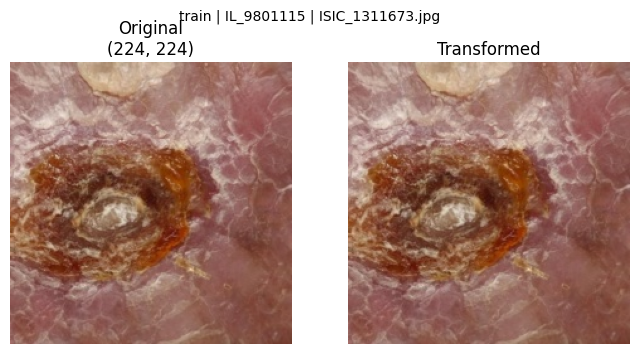

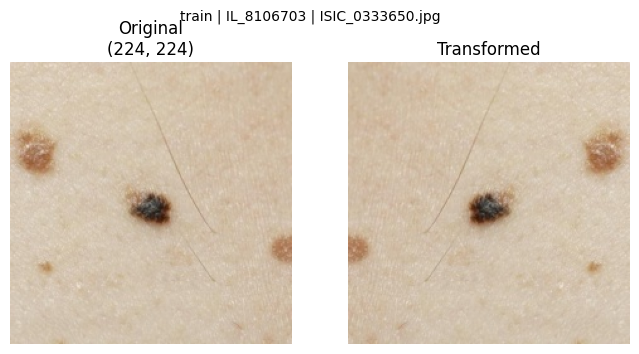

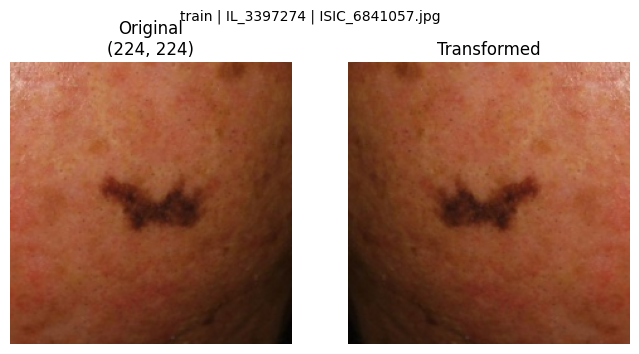

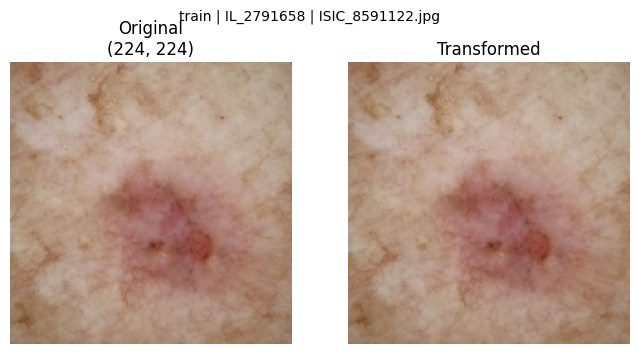

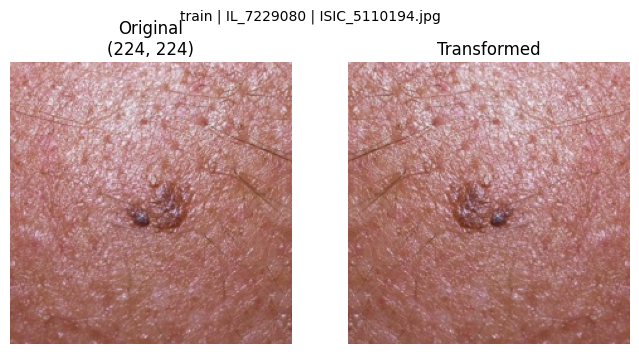

In [6]:
plot_transformed_images(
    dataset_root=DATASET_RESIZED,
    split_type="train",
    transform=data_transform,
    n=5
)



## 2 TRY: Use Resnet50 as a backbone and just add a new classification at the end for the 11 classes:

Model: ResNet50 with custom fully connected head
Description:
This model uses a pretrained ResNet50 backbone (trained on ImageNet) as a feature extractor. The backbone layers are frozen during training to retain the pretrained features, and a custom head is added for classification into 11 skin lesion categories. The head consists of:

Fully connected layer: 2048 -> 512 neurons

ReLU activation

Dropout (p=0.3)

Fully connected layer: 512 -> 11 neurons (output classes)


The forward pass computes features through the ResNet50 backbone and then passes them through the custom head to produce class logits.

Training procedure:
Loss function: CrossEntropyLoss (suitable for multi-class classification)

Optimizer: Adam (default learning rate 1e-3 for head parameters)

Device: GPU (if available) or CPU

Early stopping: Stops training if validation loss does not improve for 5 consecutive epochs

Checkpointing: Saves the best model (lowest validation loss) to a specified path

Metrics:
Training and validation accuracy: computed as (correct_predictions / total_samples) per epoch
Reported metrics:
Train Loss and Train Accuracy
Validation Loss and Validation Accuracy

This setup trains only the custom head while keeping the backbone frozen, leveraging pretrained representations for efficient convergence and avoiding overfitting given limited domain-specific data.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import copy
import os

def train_model(
    model,
    train_loader,
    val_loader,
    device,
    criterion=None,
    optimizer=None,
    num_epochs=25,
    patience=5,
    save_path="best_model.pth"
):
    """
    Generic training loop for any PyTorch model.

    Parameters:
    - model: nn.Module, the model to train
    - train_loader: DataLoader for training set
    - val_loader: DataLoader for validation set
    - device: torch.device
    - criterion: loss function (default: CrossEntropyLoss)
    - optimizer: optimizer (default: Adam for all model parameters)
    - num_epochs: max number of epochs
    - patience: early stopping patience
    - save_path: where to save the best model
    """

    model = model.to(device)

    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = running_corrects / total
        print(f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels).item()
                val_total += labels.size(0)

        val_epoch_loss = val_loss / val_total
        val_epoch_acc = val_corrects / val_total
        print(f"Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")

        # Check for improvement
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({
                'epoch': epoch+1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_epoch_loss
            }, save_path)
            print(f"Saved best model to {save_path}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epochs")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model


In [ ]:
num_classes = 11

# Load pretrained ResNet50
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False

# Custom final layers
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)  # 11 classes
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_model = train_model(
    model=resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=50,
    patience=5,
    save_path=f"{CHECKPOINT_DIR}/milk10k_best_model_resnet_first_3.pth"
)

Epoch 1/50
--------------------
Train Loss: 1.4300 Acc: 0.5520
Val Loss: 1.1775 Acc: 0.6199
Saved best model to checkpoints/milk10k_best_model_resnet_first_3.pth
Epoch 2/50
--------------------
Train Loss: 1.2830 Acc: 0.5730
Val Loss: 1.1665 Acc: 0.6316
Saved best model to checkpoints/milk10k_best_model_resnet_first_3.pth
Epoch 3/50
--------------------
Train Loss: 1.2474 Acc: 0.5899
Val Loss: 1.2170 Acc: 0.6179
No improvement for 1 epochs
Epoch 4/50
--------------------
Train Loss: 1.2488 Acc: 0.5944
Val Loss: 1.1404 Acc: 0.6491
Saved best model to checkpoints/milk10k_best_model_resnet_first_3.pth
Epoch 5/50
--------------------
Train Loss: 1.2067 Acc: 0.6116
Val Loss: 1.1430 Acc: 0.6433
No improvement for 1 epochs
Epoch 6/50
--------------------
Train Loss: 1.2262 Acc: 0.6025
Val Loss: 1.0925 Acc: 0.6452
Saved best model to checkpoints/milk10k_best_model_resnet_first_3.pth
Epoch 7/50
--------------------
Train Loss: 1.1976 Acc: 0.6118
Val Loss: 1.1427 Acc: 0.6296
No improvement for 1

## 3 TRY: ResNet50 for backbone with unfreezing of last ResNet block (layer 4) and custom classifier head.
Model: ResNet50 with custom multi-layer head and partial backbone fine-tuning

Description:

This model uses a pretrained ResNet50 backbone (ImageNet) as a feature extractor. All backbone layers are initially frozen, except for the last ResNet block (layer4), which is left trainable to allow domain-specific fine-tuning. The original fully connected layer is removed and replaced with a custom classifier head designed for 11 skin lesion classes:

- Fully connected layer: 2048 -> 1024 neurons

- Batch normalization

- ReLU activation

- Dropout

- Fully connected layer: 1024 -> 256 neurons

- Batch normalization

- ReLU activation

- Dropout

- Fully connected layer: 256 -> 11 neurons (output classes)

The forward pass computes features through the backbone (with last block trainable) and then passes them through the classifier head.

Training procedure:

Loss function: CrossEntropyLoss with class weights to handle class imbalance (weights are inversely proportional to class frequency)

Optimizer: AdamW with differential learning rates:
- 1e-4 for backbone layer4

- 1e-3 for classifier head

Weight decay = 1e-4

Device: GPU (if available) or CPU

Early stopping: Stops training if validation loss does not improve for 5 consecutive epochs

Checkpointing: Saves the best model (lowest validation loss) to a specified path

Metrics:

Training and validation accuracy: computed per epoch as (correct_predictions / total_samples)

Reported metrics:

Train Loss and Train Accuracy

Validation Loss and Validation Accuracy

This setup allows the model to leverage pretrained features while fine-tuning the last ResNet block for domain adaptation and training a more expressive classifier head, improving performance on underrepresented classes via weighted loss.


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class ResNet50MILK(nn.Module):
    def __init__(self, num_classes=11, dropout=0.5):
        super().__init__()

        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )

        # Freeze everything
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last ResNet block
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        self.backbone.fc = nn.Identity()  # remove original classifier

        self.classifier = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


In [ ]:
model = ResNet50MILK(num_classes=11).to(device)

optimizer = torch.optim.AdamW(
    [
        {"params": model.backbone.layer4.parameters(), "lr": 1e-4},
        {"params": model.classifier.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4
)


In [ ]:
import numpy as np
import torch

class_counts = train_df["label_code"].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

weights = torch.tensor(class_weights.values, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)


In [ ]:
best_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=50,
    patience=5,
    save_path=f"{CHECKPOINT_DIR}/2_milk10k_resnet50_best_second_3.pth"
)


Epoch 1/50
--------------------
Train Loss: 2.1910 Acc: 0.2988
Val Loss: 1.8455 Acc: 0.4230
Saved best model to checkpoints/2_milk10k_resnet50_best_second_3.pth
Epoch 2/50
--------------------
Train Loss: 1.8539 Acc: 0.4103
Val Loss: 1.7232 Acc: 0.5049
Saved best model to checkpoints/2_milk10k_resnet50_best_second_3.pth
Epoch 3/50
--------------------
Train Loss: 1.6369 Acc: 0.4440
Val Loss: 1.6779 Acc: 0.5166
Saved best model to checkpoints/2_milk10k_resnet50_best_second_3.pth
Epoch 4/50
--------------------
Train Loss: 1.5714 Acc: 0.4576
Val Loss: 1.5862 Acc: 0.5400
Saved best model to checkpoints/2_milk10k_resnet50_best_second_3.pth
Epoch 5/50
--------------------
Train Loss: 1.4563 Acc: 0.4709
Val Loss: 1.6889 Acc: 0.5166
No improvement for 1 epochs
Epoch 6/50
--------------------
Train Loss: 1.3688 Acc: 0.4764
Val Loss: 1.7923 Acc: 0.5185
No improvement for 2 epochs
Epoch 7/50
--------------------
Train Loss: 1.2453 Acc: 0.5141
Val Loss: 1.8013 Acc: 0.5205
No improvement for 3 epo

## 4 TRY: ResNet50 with a custom head

## 5 TRY: ResNet50 with custom head and two-stage training

Model Overview:
The model is a ResNet50-based classifier adapted for the 11 classes. The architecture uses a pretrained ResNet50 backbone (ImageNet weights), with the original fully connected (FC) layer replaced by a custom head:

Head structure:

- Linear layer: 2048 → 512 → BatchNorm → ReLU → Dropout(0.5)

- Linear layer: 512 → 128 → BatchNorm → ReLU → Dropout(0.5)

- Linear layer: 128 → 11 (output classes)

The forward pass extracts features via the backbone and passes them through the head to produce logits for the 11 classes.

Training Strategy:
Training is performed in two stages:

- Stage 1 – Train head only:

The ResNet backbone is fully frozen (requires_grad=False).

Only the custom head layers are trained.

Optimizer: AdamW with lr=1e-3

Loss function: CrossEntropyLoss

Early stopping with patience = 5 epochs

Best model based on validation loss is saved

- Stage 2 – Fine-tune last ResNet block:

The last ResNet block (layer4) is unfrozen.

Both the last block and the head are trained.

Optimizer: AdamW with a smaller learning rate (lr=1e-5) for fine-tuning.

Loss function: CrossEntropyLoss

Early stopping with patience = 5 epochs

Best model based on validation loss is saved

Evaluation Metrics:

The primary metric used for performance is accuracy, computed as the fraction of correct predictions over all samples.

Both training and validation phases report loss (CrossEntropyLoss) and accuracy.

Early stopping is applied based on validation loss, ensuring the best-performing weights are saved.

Additional Notes:

The two-stage strategy leverages transfer learning: pretrained weights are preserved in Stage 1 to avoid catastrophic forgetting, while Stage 2 adapts the backbone to the specific MILK10k dataset.

Batch normalization and dropout in the head help with regularization and stabilize training.

This approach allows experimentation with weighted or focal loss if class imbalance becomes an issue.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=11, dropout=0.5):
        super().__init__()

        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

def freeze_backbone(model):
    for param in model.backbone.parameters():
        param.requires_grad = False

def unfreeze_last_block(model):
    for name, param in model.backbone.named_parameters():
        if "layer4" in name:
            param.requires_grad = True

from sklearn.metrics import accuracy_score
import numpy as np

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds.append(outputs.argmax(dim=1).cpu())
        targets.append(labels.cpu())

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    acc = accuracy_score(targets, preds)
    return total_loss / len(loader.dataset), acc

import copy

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    patience=5,
    save_path="best_model.pt"
):
    best_val_loss = float("inf")
    patience_counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        print(
            f"Epoch [{epoch}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
            print("Best model saved")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_weights)
    return model


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet50Classifier(num_classes=11).to(device)

# Stage 1: train head only
freeze_backbone(model)

criterion = nn.CrossEntropyLoss()  # replace with weighted or focal later
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=20,
    patience=5,
    save_path=f"{CHECKPOINT_DIR}/best_stage1_resnet_4_3.pt"
)

# Stage 2: fine-tune last ResNet block
unfreeze_last_block(model)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=5,
    save_path=f"{CHECKPOINT_DIR}/best_stage2_resnet_4_3.pt"
)


Epoch [1/20] | Train Loss: 1.4711 | Val Loss: 1.1329 | Val Acc: 0.6569
Best model saved
Epoch [2/20] | Train Loss: 1.2542 | Val Loss: 1.1176 | Val Acc: 0.6394
Best model saved
Epoch [3/20] | Train Loss: 1.2153 | Val Loss: 1.0974 | Val Acc: 0.6472
Best model saved
Epoch [4/20] | Train Loss: 1.2048 | Val Loss: 1.0560 | Val Acc: 0.6667
Best model saved
Epoch [5/20] | Train Loss: 1.1496 | Val Loss: 1.0604 | Val Acc: 0.6608
Epoch [6/20] | Train Loss: 1.1465 | Val Loss: 1.0511 | Val Acc: 0.6647
Best model saved
Epoch [7/20] | Train Loss: 1.1593 | Val Loss: 1.0547 | Val Acc: 0.6667
Epoch [8/20] | Train Loss: 1.1401 | Val Loss: 1.0417 | Val Acc: 0.6569
Best model saved
Epoch [9/20] | Train Loss: 1.1275 | Val Loss: 1.0365 | Val Acc: 0.6472
Best model saved
Epoch [10/20] | Train Loss: 1.1270 | Val Loss: 1.0495 | Val Acc: 0.6589
Epoch [11/20] | Train Loss: 1.1234 | Val Loss: 1.0453 | Val Acc: 0.6647
Epoch [12/20] | Train Loss: 1.1023 | Val Loss: 1.0313 | Val Acc: 0.6647
Best model saved
Epoch [13